# spotWithAnnularContrastReversingGrating — reversing annular grating

The reversing sibling of `analyze_flash_grate.ipynb`, with the same structure — discover, group,
keep the canonical conditions, schematic, analyze, store, population figure — and sharing that
notebook's helpers for light level, the cone model and the grouping logic.

**The stimulus** is the same annular square-wave grating, now reversing at
`currentTemporalFrequency`. Two details from
`chris-package/.../spotWithAnnularContrastReversingGrating.m` matter:

* The protocol's comment describes a sinusoid, but `getGratingFrame` applies
  `sign(cos(2·pi·f·t))` — the reversal is a **square wave** alternating between two fixed frames.
* The frames are asymmetric: with `Ap = brightBarContrast` and `An = |darkBarContrast|`, one
  frame puts the bright-bar set at `-An` and the dark set at `+Ap`, the other swaps them. At
  onset `sign(cos 0) = +1` selects the inverted frame, called **phase A** here.

**This protocol does not measure the flashed protocol's cancellation null.** At every instant
half the bars sit at `+Ap` and half at `-An` — reversing swaps *which* bars, not the set of
intensities on screen. A receptive field centred on the grating therefore gets the same drive in
both half cycles, so the bright/dark balance has nothing to null. (In the flashed version the two
bar sets are presented simultaneously and summed, which is what makes them cancel.) What the
reversal modulates is the spatial arrangement, and rectifying subunits turn that into a
frequency-doubled response.

So the measurement here is a **contrast-response function**: F1 and F2 amplitude versus
dark-bar contrast. The half-cycle difference is kept as a check on the symmetry argument — it
should sit at zero, and a large value means the grating was not centred on the cell.

In [1]:
# Pick up edits to the retinanalysis package without restarting the kernel.
%load_ext autoreload
%autoreload 2

import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_crg as crg

# ---- analysis settings -------------------------------------------------
# These mirror analyze_flash_grate.ipynb one for one, because the two
# protocols share a rig, a light path and a cell population -- a recording
# rejected there should be rejected here for the same reason.

# Filter-wheel settings that count as analyzable. NDF 2/3/4 are uncalibrated
# and land at single-digit R*, so they are dropped.
FILTER_WHEEL = (0.0, 0.5, 1.0)

# Bright-bar contrasts to analyze. Every CRG block ran at 0.9, so this is a
# no-op here -- it is kept so the two notebooks cannot drift apart.
BRIGHT_CONTRAST = (0.9, 1.0)

# Reversal frequencies to keep. Both (2 and 4 Hz) are analyzed by default;
# unlike bar width this is a grouping key, never pooled, because F1 and F2 are
# measured at it. Set to e.g. (4.0,) to restrict.
TEMPORAL_FREQUENCY = None

# Minimum bar width in microns -- below this the optics low-pass the grating
# before it reaches the photoreceptors. Drops the 50 um blocks.
MIN_BAR_WIDTH = 60.0

# Fewest epochs a pooled recording group may rest on.
MIN_EPOCHS = 16

# Access-resistance cutoff for whole-cell epochs, in ohms.
MAX_SERIES_RESISTANCE = 20e6


## 1. Find every block that ran the protocol

Same columns as the flashed notebook plus `temporalFrequency` and `barWidth`, both constant
within a block. Light level is `background:FilterWheel:NDF` plus `backgroundIntensity`, and
uncalibrated combinations keep `rstar = NaN` rather than being estimated — attach your own
conversion with `crg.apply_rstar_mapping` when you have it.

In [2]:
df_blocks = crg.find_blocks()

35 blocks | 5 experiments | 12 cells


exp_name,cell_label,cell_type_short,onlineAnalysis,grating_site,temporalFrequency,barWidth,filter_wheel_ndf,backgroundIntensity,light_level,annulusInnerDiameter,annulusOuterDiameter,stimTime,n_epochs,block_id
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,22,34330
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,150.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,22,34333
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,14,34334
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,75.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,11,34324
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,75.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,12,34325
2026-04-23_E,Cell3,horizontal,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,14,34315
2026-04-23_E,Cell3,horizontal,extracellular,center,4.0,150.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,22,34317
2026-04-23_E,Cell4,horizontal,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,12,34305
2026-04-23_E,Cell4,horizontal,extracellular,center,4.0,150.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,22,34306
2026-04-23_E,Cell4,horizontal,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,22,34309


### 1b. Is each block the kind of recording it says it is?

Identical in kind to the flashed notebook's section 1b, and it uses the same function —
`onlineAnalysis` is a menu item the experimenter picks before a block runs, and it gets picked
wrong. Symphony writes `stimulus:Amp1:seriesResistance` into every epoch, and it is **exactly 0
for a cell-attached recording**, so the amplifier settles it. Where the reading contradicts the
label the block is relabelled and analyzed correctly rather than thrown away, with the recorded
label kept in `onlineAnalysis_recorded`.

This matters here even though almost every CRG block is already labelled `extracellular`: the one
that is not, **2026-05-06_E Cell3**, is labelled `exc` but has a series resistance of 0 and a
trace full of spikes. Without this step it would go through the whole-cell path and have its
spikes averaged as if they were picoamps, then be reported in pA.

The `stimTime` / frame-rate warnings that scroll past come from the stimulus-timing reader, not
from this check; the series-resistance read itself reports its own coverage.

In [ ]:
df_blocks = crg.check_series_resistance(df_blocks,
              max_series_resistance=MAX_SERIES_RESISTANCE)

## 2. Group, then keep the canonical conditions

A group is experiment × cell × recording mode × grating site × **temporal frequency** ×
filter wheel × background. Temporal frequency is a grouping key here because it changes the
response; bar width is pooled, as in the flashed analysis.

**The table is ordered by cell, not by epoch count**, the same way `analyze_flash_grate.ipynb`
orders its section 2. Every recording of one cell on one date sits on consecutive rows under a
single `<experiment>/<cell>` heading, because those rows are the same cell at different temporal
frequencies and light levels and reading them against each other is the point. Within a cell the
rows run most epochs first, and cells and experiments are ranked by their totals, so the
best-sampled cell is still near the top. `canonical` itself is stored in that order, so the index
in the first column is the row number sections 3b and 4 take.


In [ ]:
groups = crg.group_blocks(df_blocks,
                          allowed_filter_wheel=FILTER_WHEEL,
                          allowed_bright_contrast=BRIGHT_CONTRAST,
                          allowed_temporal_frequency=TEMPORAL_FREQUENCY,
                          min_bar_width=MIN_BAR_WIDTH,
                          min_epochs=MIN_EPOCHS)
canonical = crg.select_canonical(groups)

# One cell's recordings on adjacent rows, as in analyze_flash_grate.ipynb:
# experiments ranked by total epochs, cells within an experiment the same way,
# and a cell's own recordings by epochs. Sorting on epochs alone scattered a
# cell down the table -- 2026-06-04_G/Cell2 has four light levels -- and here
# those rows are exactly what you want to read against each other, since
# temporal frequency and light level are the conditions that vary within a cell.
canonical = (canonical
             .assign(_exp=canonical.groupby('exp_name')['epochs'].transform('sum'),
                     _cell=canonical.groupby(['exp_name', 'cell_label'])['epochs']
                                    .transform('sum'))
             .sort_values(['_exp', 'exp_name', '_cell', 'cell_label', 'epochs'],
                          ascending=[False, True, False, True, False])
             .drop(columns=['_exp', '_cell'])
             .reset_index(drop=True))

# Displayed as a tree keyed on the cell: the id repeats only on the row that
# starts a new cell, with a rule above it. `cell` is the '<experiment>/<cell>'
# id describe_cell(), inspect_cell() and the CELL setting at the bottom take.
# The index is what sections 3b and 4 select with RAW_PICK and PICK.
disp = canonical.reset_index()
disp['cell'] = disp['exp_name'] + '/' + disp['cell_label']
cols = ['index', 'cell', 'rig', 'cell_type_short', 'onlineAnalysis', 'grating_site',
        'center_spot', 'temporalFrequency', 'bar_width', 'bright', 'filter_wheel_ndf',
        'backgroundIntensity', 'rstar', 'rstar_level', 'blocks', 'epochs']
cols += [c for c in ('rs_mohm',) if c in disp.columns]
sc.tree_table(disp[cols].round({'rstar': 0}),
    levels=['cell', 'rig', 'cell_type_short'],
    height=340, num_cols=('index', 'temporalFrequency', 'filter_wheel_ndf',
                          'backgroundIntensity', 'rstar', 'rstar_level', 'blocks',
                          'epochs', 'rs_mohm'))

# The two stimulus axes this protocol adds to the flashed one. Bar width is
# pooled by analyze_group; temporal frequency is a grouping key, because F1 and
# F2 are measured at it.
print('\nbar width x temporal frequency (recordings)')
display(pd.crosstab(groups['bar_width'], groups['temporalFrequency']))

print('\nlight level x temporal frequency (recordings)')
display(pd.crosstab([groups['rig'], groups['rstar_level']], groups['temporalFrequency']))

In [4]:
print('cell type x grating site (blocks)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['grating_site']))

print('\ncell type x recording mode (blocks)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['onlineAnalysis']))

cell type x grating site (blocks)


grating_site,center,surround
cell_type_short,,
OFF-parasol,18,0
ON-parasol,7,4
bipolar,1,0
horizontal,5,0



cell type x recording mode (blocks)


onlineAnalysis,exc,extracellular
cell_type_short,,
OFF-parasol,0,18
ON-parasol,0,11
bipolar,1,0
horizontal,0,5


Two things to note in those tables, both limits of the dataset rather than the code:

* **There is no whole-cell parasol data for this protocol.** The single `exc` block is a bipolar
  cell, so the `exc` panels below are empty.
* Most ON-parasol recordings put the grating over the **center**, the non-canonical pairing, so
  only a couple of ON-parasol/surround groups survive `select_canonical`.

## 3. Stimulus schematic

The two half-cycle frames and the square wave they alternate on. Phase A is what appears at
stimulus onset.

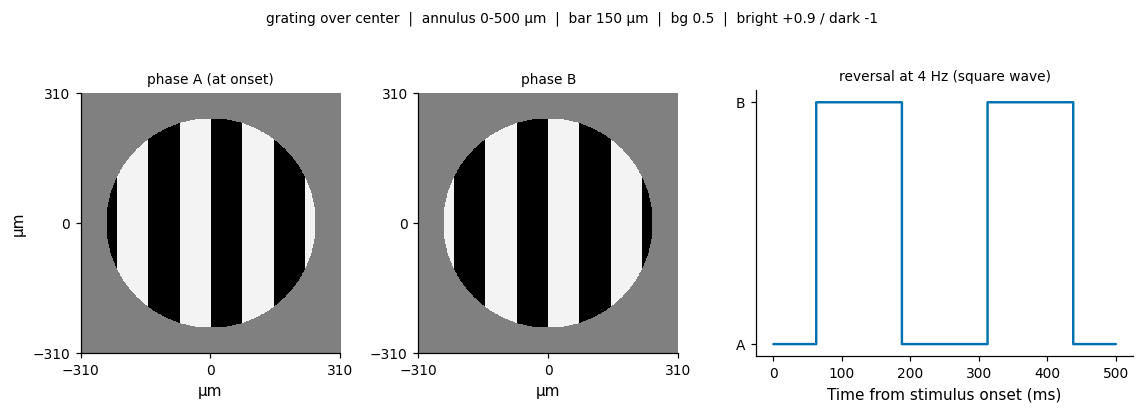

In [5]:
def block_params(block_id):
    exp = df_blocks.loc[df_blocks.block_id.eq(block_id), 'exp_name'].iloc[0]
    return ra.StimBlock(exp, int(block_id), verbose=False).df_epochs['epoch_parameters'].iloc[0]

first_block = int(canonical.block_ids.iloc[0].split(',')[0])
crg.plot_stimulus_schematic(block_params(first_block));

### The reversal as a movie

The two frames above alternate on the protocol's own schedule, `sign(cos(2·pi·f·t))`. A second
and a half of it, at the block's own temporal frequency.

In [6]:
crg.animate_stimulus(block_params(first_block), duration_s=1.5)

## 3b. The raw data, before anything is done to it

`SCResponseBlock` stores `amp_data` exactly as the amplifier wrote it — the high-pass filter that
precedes spike detection is applied inside the detector, not to this array — so these are the
traces with no filtering, smoothing, folding or spike sorting. Worth a look before trusting any
harmonic amplitude: a cell lost partway through a block, a drifting baseline, or a gain change
between the blocks a group pools will all quietly bias F1 and F2 without failing.

`plot_raw_blocks` gives one panel per block with every epoch overlaid and the block's series
resistance in the title; `plot_raw_epochs` regroups the same traces by dark-bar contrast and adds
the spike raster for a cell-attached recording. Both are the flashed protocol's functions,
re-exported rather than reimplemented — they read `amp_data` and the epoch timing, which this
protocol has too.

In [ ]:
RAW_PICK = 0        # row index from the section 2 table

_row = canonical.loc[RAW_PICK]
_bids = [int(b) for b in str(_row.block_ids).split(',')]
print(f'[{RAW_PICK}] {_row.exp_name} {_row.cell_label} — {_row.onlineAnalysis}, '
      f'{_row.temporalFrequency:g} Hz, bar {_row.bar_width} µm, '
      f'{_row.rstar_level:g} R*, blocks {_bids}')

crg.plot_raw_blocks(_row.exp_name, _bids, online_analysis=_row.onlineAnalysis)
crg.plot_raw_epochs(_row.exp_name, _bids, online_analysis=_row.onlineAnalysis,
                    max_contrasts=4);

## 4. Analyze one recording, or several of one cell

`PICK` takes a row index from the section 2 table, or a list of them — `PICK = 0` and
`PICK = [0, 1, 2, 3]` both work, exactly as in `analyze_flash_grate.ipynb`. Since that table is
ordered by cell, one cell's conditions are consecutive rows, so a slice of consecutive indices
*is* a cell. Each cell's full condition list is printed first, so you can see what the pick
leaves out.

**Per recording.** Each epoch's stimulus window is folded into reversal cycles (dropping the
first, which carries the onset transient), then F1 and F2 amplitudes are measured on that window.
Top: the mean reversal cycle per dark contrast — two response bursts per cycle, one at each
reversal, which *is* the frequency doubling. Middle: the contrast-response function. Bottom: the
half-cycle difference, the symmetry check.

**Across the picks**, `plot_tuning_overlay` puts every chosen contrast-response curve on one pair
of axes. Left is `HARMONIC` in recorded units, one panel per unit; right is every curve divided
by its own amplitude at its most negative dark contrast, so each starts at 1 there and what
remains is the *shape* of the contrast dependence — whether a dimmer light level or a slower
reversal changes how fast the response grows with contrast, rather than how large it is. The
divisor is a magnitude, so it is positive and no curve is reflected.

Two differences from the flashed notebook's overlay, both because a reversing grating measures
something else. There is **no baseline to subtract** — a harmonic amplitude is already a
modulation depth, zero when the cell does not follow the grating — and there is **no crossing
marker**, since F2 rises with contrast instead of returning to zero. The null this protocol can
still speak to lives in `resp_mean`, the half-cycle difference; pass
`crg.plot_tuning_overlay(recs, harmonic='resp_mean', subtract_baseline=True)` to overlay that
instead.

Color is the light level on the sequential ramp, dash the recording mode, marker the grating
site, and the automatic legend names each recording's temporal frequency. `crg.tuning_overlay`
returns the numbers behind both panels, including the amplitude each curve was divided by.


In [ ]:
# One row index from the section 2 table, or several of them. Because that
# table is ordered by cell, a cell's conditions are consecutive rows, so a slice
# picks a cell out of it: PICK = 0 analyzes one recording, PICK = [6, 7, 8, 9]
# the four rows of 2026-06-04_G/Cell2 -- one cell at four light levels -- and
# then overlays their contrast-response curves.
PICK = [6, 7, 8, 9]

# Which harmonic the overlay compares. F2 is the measurement for a reversing
# grating -- the frequency-doubled response of rectifying subunits -- and F1 is
# the same recordings' fundamental, much smaller throughout.
HARMONIC = 'f2_mean'

picks = [int(PICK)] if np.isscalar(PICK) else [int(p) for p in PICK]
rows = canonical.loc[picks]

# The overlay is meant to be one cell across conditions. It still draws for a
# mixed set, but then a difference between curves is a difference between cells
# as much as between conditions, so say so rather than let it pass.
cells = list(dict.fromkeys(f'{r.exp_name}/{r.cell_label}' for r in rows.itertuples()))
if len(cells) > 1:
    print(f'note: these {len(picks)} rows span {len(cells)} cells '
          f'({", ".join(cells)}) -- the overlay below compares cells, not conditions\n')

# Before analyzing, see what else each cell has: the other conditions it was
# recorded in, and whether the rows picked are representative.
for cell in cells:
    crg.describe_cell(cell, canonical)

recs = []
for pick, row in rows.iterrows():
    print(f'\n=== [{pick}] {row.exp_name} {row.cell_label} — {row.onlineAnalysis}, '
          f'grating over {row.grating_site}, {row.temporalFrequency:g} Hz, '
          f'{row.light_setting} ({row.epochs} epochs) ===')
    rec = crg.analyze_group(row.exp_name, [int(b) for b in row.block_ids.split(',')],
                            online_analysis=row.onlineAnalysis)
    recs.append(rec)
    crg.plot_group(rec)

# What picking several rows is for: their contrast-response curves on one pair
# of axes, in recorded units and normalized to each curve's own amplitude at its
# deepest dark bar, so frequencies and light levels can be read against each
# other. No crossing marker here -- F2 rises with contrast rather than returning
# to zero, so the null lives in the half-cycle difference, not in this curve.
if len(recs) > 1:
    labels = [f'[{p}] {r.temporalFrequency:g} Hz · {r.light_setting} · {r.grating_site}'
              for p, r in zip(picks, rows.itertuples())]
    crg.plot_tuning_overlay(recs, harmonic=HARMONIC, labels=labels)

    print(f'\nwhat each {HARMONIC.split("_")[0].upper()} curve was divided by')
    overlay = crg.tuning_overlay(recs, harmonic=HARMONIC)
    overlay['pick'] = [picks[p] for p in overlay['position']]
    display(overlay.groupby(['pick', 'cell', 'temporal_frequency', 'grating_site',
                             'light_level'], sort=True)
            .agg(epochs=('n_epochs', 'first'), units=('units', 'first'),
                 ref_contrast=('ref_contrast', 'first'),
                 ref_amplitude=('ref_amplitude', 'first')).round(2).reset_index());

## 5. Batch analyze and save

Records go to `<OUTPUT_DIR>/spot_annular_crg/records.h5` with a `summary.csv` index, upserted per
(experiment, cell, mode, grating site, temporal frequency, filter wheel, background) — the same
layout as the flashed protocol, in its own directory.

In [8]:
# Same two switches as the flashed notebook: an explicit re-run decision rather
# than an automatic skip, and an explicit prune of records that are no longer in
# `canonical`. `crg.prune_records(canonical, dry_run=True)` lists what would go.
REANALYZE = True
PRUNE_STORE = True

records = crg.analyze_all(canonical, save=True, plot=False,
                          skip_existing=not REANALYZE, prune=PRUNE_STORE,
                          max_series_resistance=MAX_SERIES_RESISTANCE)

analyzed 0/17 groups (17 already stored, skipped)


## 6. Population contrast-response

One panel per condition × recording mode, one line per recording, coloured by light setting.
This replaces the flashed notebook's crossing-vs-Weber figure, which does not apply here.

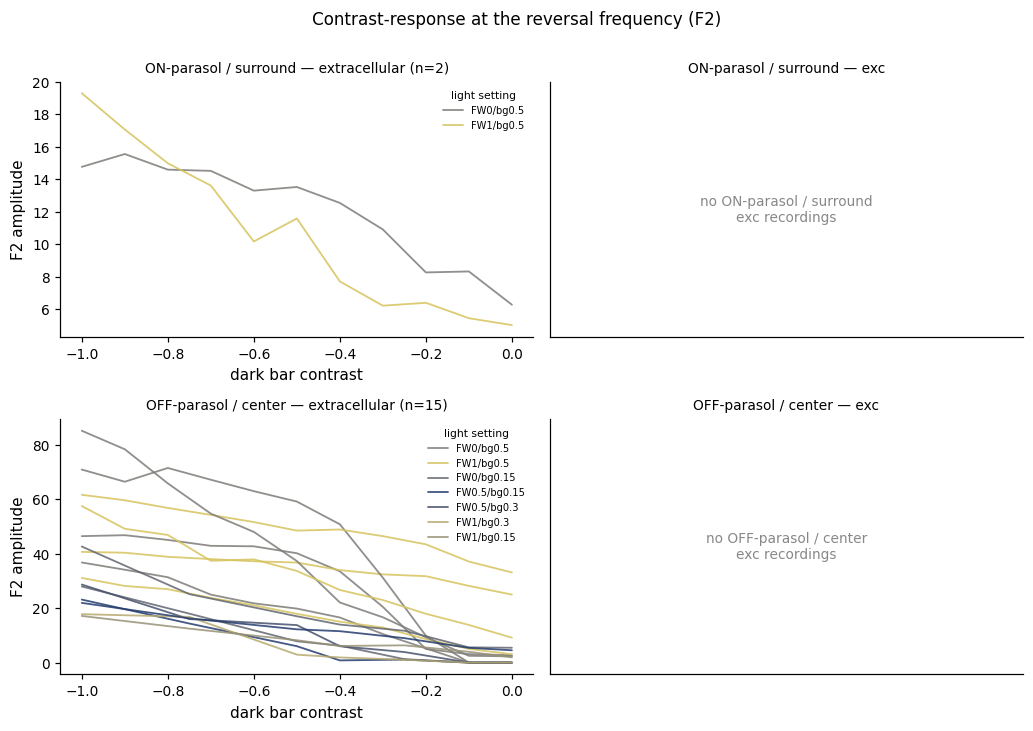

In [9]:
crg.plot_contrast_response();

### F2 by light level

The same contrast-response curves, but pooled across cells and split by light level rather than
by recording — the CRG twin of the population tuning curves in the flashed notebook.

There is no baseline to subtract here: an amplitude at the reversal frequency is already a
modulation depth, zero when the cell does not follow the grating. Each cell is divided by its own
peak amplitude, for the same reason as the flashed protocol — cells differ enormously in absolute
response, so a raw mean would be the loudest cell plus noise — and since the divisor is a positive
scalar the shape of every curve survives it.

Panels split on temporal frequency as well as condition, because 2 and 4 Hz are different stimuli
and the harmonics are measured at them. Light level is ordered, so the curves use the house
sequential ramp (`cividis`, dim → bright) with the mapping built once across every level, so a
given R* is the same color in every panel.

Coverage is thin — most (condition, frequency, light level) cells rest on one or two cells — so
read this as what the dataset can currently support rather than a population result.

In [ ]:
summary = crg.add_condition(crg.load_summary())
crg.plot_population_contrast_response(summary)

tuning = crg.population_contrast_response(summary)
display(tuning.groupby(['condition', 'temporal_frequency', 'rstar_level'])
               .agg(contrasts=('dark_contrast', 'size'),
                    cells=('n_cells', 'max')).reset_index())

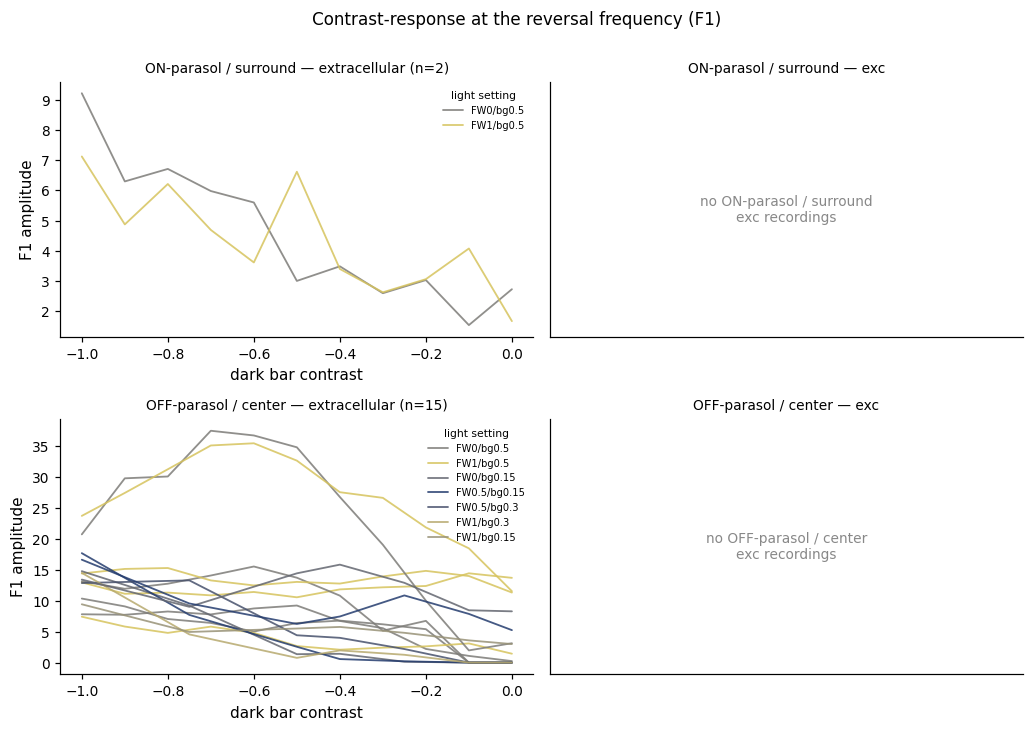

In [10]:
# F1 for the same recordings: much smaller than F2 throughout, which is the
# signature of a frequency-doubling response to a reversing grating.
crg.plot_contrast_response(harmonic='f1_mean');

### Is there any balance point hiding in these curves?

If the bright/dark balance mattered, a harmonic would dip at some intermediate contrast. It does
not: F2 rises monotonically with dark-bar contrast in every recording. The correlation of F2 with
|dark contrast| is computed per record below.

In [11]:
rows = []
for key, r in crg.load_records().items():
    x = np.abs(r['dark_contrasts'])
    rows.append({'cell': f"{r['exp_name']} {r['cell_label']}",
                 'mode': r['online_analysis'], 'Hz': float(r['temporal_frequency']),
                 'light': r['light_setting'],
                 'corr(|dark|, F1)': np.corrcoef(x, r['f1_mean'])[0, 1],
                 'corr(|dark|, F2)': np.corrcoef(x, r['f2_mean'])[0, 1],
                 'median F2/F1': float(np.median(r['f2_mean'] / np.maximum(r['f1_mean'], 1e-9)))})
mono = pd.DataFrame(rows).round(2)
print(f"F2 rises with contrast in {int((mono['corr(|dark|, F2)'] > 0.9).sum())}/{len(mono)} "
      f"recordings (correlation > 0.9)")
sc.scroll_table(mono, height=300)

F2 rises with contrast in 17/17 recordings (correlation > 0.9)


cell,mode,Hz,light,"corr(|dark|, F1)","corr(|dark|, F2)",median F2/F1
2026-04-23_E Cell1,extracellular,4.0,FW0/bg0.5,0.83,0.93,4.97
2026-04-23_E Cell1,extracellular,4.0,FW1/bg0.5,-0.57,0.97,3.13
2026-04-23_E Cell2,extracellular,4.0,FW0/bg0.5,0.83,0.93,4.69
2026-04-23_E Cell2,extracellular,4.0,FW1/bg0.5,0.49,0.98,3.71
2026-04-23_E Cell5,extracellular,4.0,FW0/bg0.5,0.92,0.94,2.47
2026-04-23_E Cell5,extracellular,4.0,FW1/bg0.5,0.77,0.97,2.41
2026-04-23_E Cell6,extracellular,4.0,FW0/bg0.5,0.86,0.99,3.1
2026-04-23_E Cell6,extracellular,4.0,FW1/bg0.5,0.89,1.0,4.36
2026-04-24_E Cell2,extracellular,4.0,FW0/bg0.5,0.71,0.99,1.26
2026-04-24_E Cell2,extracellular,4.0,FW1/bg0.5,0.62,0.99,1.03


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:300px"><table><thead><tr><th>cell</th><th>mode</th><th>Hz</th><th>light</th><th>corr(|dark|, F1)</th><th>corr(|dark|, F2)</th><th>median F2/F1</th></tr></thead><tbody><tr><td>2026-04-23_E Cell1</td><td>extracellular</td><td>4.0</td><td>FW0/bg0.5<

## 7. Come back later

`load_summary()` reads the scalar index without touching DataJoint or the SSD; `load_records()`
pulls the arrays. `crg.plot_condition_examples()` also works, but note its tuning panel shows the
half-cycle difference — the symmetry check — not the contrast-response.

In [12]:
summary = crg.add_condition(crg.load_summary())
sc.scroll_table(summary[['exp_name', 'cell_label', 'cell_type_short', 'online_analysis',
                         'grating_site', 'temporal_frequency', 'light_setting',
                         'f1_max', 'f2_max', 'n_epochs']], height=320)

exp_name,cell_label,cell_type_short,online_analysis,grating_site,temporal_frequency,light_setting,f1_max,f2_max,n_epochs
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,9.2397369464734,46.80062987197675,36
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,14.456656185414014,40.66824831043698,22
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,15.55697787411701,71.49097730083882,12
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,15.310712654323886,61.63275946659227,11
2026-04-23_E,Cell6,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,10.367062141366173,36.77063547594333,25
2026-04-23_E,Cell6,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,7.431352706687701,31.096667951593,22
2026-04-24_E,Cell2,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,37.5304495619578,85.16166784707362,22
2026-04-24_E,Cell2,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,35.5038384813849,57.50783357931,22
2026-06-04_G,Cell2,OFF-parasol,extracellular,center,2.0,FW0/bg0.15,14.798481845422295,27.955226038945046,21
2026-06-04_G,Cell2,OFF-parasol,extracellular,center,2.0,FW0.5/bg0.15,17.713975540364476,23.144278843424292,21


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:320px"><table><thead><tr><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>online_analysis</th><th>grating_site</th><th>temporal_frequency</th><th>light_setting</th><th>f1_max</th><th>f2_max</th><th>n_epochs</th></tr></thead><tbody>

## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-06-04_G/Cell2'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [13]:
crg.list_cells(canonical)

7 cells, 17 recording conditions in total


cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,temporalFrequency,bar_widths,light_setting,light_level,filter_wheel_ndf,backgroundIntensity
2026-04-23_E/Cell1,OFF-parasol,2,58,extracellular,center,4.0,150,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell2,,2,23,extracellular,center,4.0,75,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell6,,2,47,extracellular,center,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-24_E/Cell2,,2,44,extracellular,center,4.0,50,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-06-04_G/Cell2,,4,84,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0.5/bg0.3, FW0/bg0.15, FW1/bg0.3","12000R*, 2000R*, 4000R*, 8000R*","0.0, 0.5, 1.0","0.15, 0.3"
2026-06-04_G/Cell3,,3,71,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0/bg0.15, FW1/bg0.15","1000R*, 12000R*, 4000R*","0.0, 0.5, 1.0",0.15
2026-04-23_E/Cell5,ON-parasol,2,72,extracellular,surround,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5


,cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,temporalFrequency,bar_widths,light_setting,light_level,filter_wheel_ndf,backgroundIntensity
0,2026-04-23_E/Cell1,OFF-parasol,2,58,extracellular,center,4.0,150,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
1,2026-04-23_E/Cell2,OFF-parasol,2,23,extracellular,center,4.0,75,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2,2026-04-23_E/Cell6,OFF-parasol,2,47,extracellular,center,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
3,2026-04-24_E/Cell2,OFF-parasol,2,44,extracellular,center,4.0,50,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
4,2026-06-04_G/Cell2,OFF-parasol,4,84,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0.5/bg0.3, FW0/bg0.15, FW1/bg0.3","12000R*, 2000R*, 4000R*, 8000R*","0.0, 0.5, 1.0","0.15, 0.3"
5,2026-06-04_G/Cell3,OFF-parasol,3,71,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0/bg0.15, FW1/bg0.15","1000R*, 12000R*, 4000R*","0.0, 0.5, 1.0",0.15
6,2026-04-23_E/Cell5,ON-parasol,2,72,extracellular,surround,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5


2026-06-04_G/Cell2  |  OFF-parasol  |  4 recording condition(s), 4 blocks, 84 epochs
  varies across conditions: light_setting = FW0.5/bg0.15, FW0.5/bg0.3, FW0/bg0.15, FW1/bg0.3; light_level = 12000R*, 2000R*, 4000R*, 8000R*; filter_wheel_ndf = 0.0, 0.5, 1.0; backgroundIntensity = 0.15, 0.3


onlineAnalysis,grating_site,temporalFrequency,bar_widths,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,blocks,epochs,block_ids
extracellular,center,2.0,80,FW0.5/bg0.15,4000R*,0.5,0.15,1,21,35031
extracellular,center,2.0,80,FW0/bg0.15,12000R*,0.0,0.15,1,21,35032
extracellular,center,2.0,80,FW1/bg0.3,2000R*,1.0,0.3,1,21,35033
extracellular,center,2.0,80,FW0.5/bg0.3,8000R*,0.5,0.3,1,21,35034


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 3427 peaks
Trial 1: Splitting data into 2 sections for KMeans clustering.
Trial 1: Found 847 spikes
Trial 1: no spikes!
Trial 2: Found 3463 peaks


Trial 2: Splitting data into 2 sections for KMeans clustering.
Trial 2: Found 892 spikes
Trial 2: no spikes!
Trial 3: Found 3423 peaks
Trial 3: Splitting data into 2 sections for KMeans clustering.
Trial 3: Found 1573 spikes
Trial 3: no spikes!
Trial 4: Found 3369 peaks


...

Trial 11: Splitting data into 2 sections for KMeans clustering.
Trial 11: Found 2 spikes
Trial 12: Found 3336 peaks
Trial 12: Splitting data into 2 sections for KMeans clustering.
Trial 12: Found 8 spikes
Trial 13: Found 3322 peaks
Trial 13: Splitting data into 2 sections for KMeans clustering.
Trial 13: Found 18 spikes
Trial 14: Found 3280 peaks


Trial 14: Splitting data into 2 sections for KMeans clustering.
Trial 14: Found 30 spikes
Trial 15: Found 3364 peaks
Trial 15: Splitting data into 2 sections for KMeans clustering.
Trial 15: Found 777 spikes
Trial 15: no spikes!
Trial 16: Found 3408 peaks
Trial 16: Splitting data into 2 sections for KMeans clustering.
Trial 16: Found 779 spikes
Trial 16: no spikes!
Trial 17: Found 3374 peaks


Trial 17: Splitting data into 2 sections for KMeans clustering.
Trial 17: Found 3 spikes
Trial 18: Found 3381 peaks
Trial 18: Splitting data into 2 sections for KMeans clustering.
Trial 18: Found 5 spikes
Trial 19: Found 3365 peaks
Trial 19: Splitting data into 2 sections for KMeans clustering.
Trial 19: Found 7 spikes
Trial 20: Found 3331 peaks


Trial 20: Splitting data into 2 sections for KMeans clustering.
Trial 20: Found 19 spikes
Trial 21: Found 3295 peaks
Trial 21: Splitting data into 2 sections for KMeans clustering.
Trial 21: Found 32 spikes


2026-06-04_G | RGC\OFF-parasol | Cell2 | extracellular | grating center | 2 Hz | FW=0.5 bg=0.30 (8000R*) | 21 epochs
  dark contrasts   : [-1.   -0.75 -0.5  -0.4  -0.25 -0.1   0.  ]
  phase A - B      : [ 2.291  5.427 -2.643  4.067 -1.767  0.     0.   ]
  F1 / F2          : [12.88 13.31  4.43  4.01  2.2   0.    0.  ] / [28.67 15.99 13.78  6.01  3.89  0.    0.  ]
  null nearest=-0.100 interp=-0.582 | cone pred=-0.369
analyzed 4/4 conditions for 2026-06-04_G/Cell2


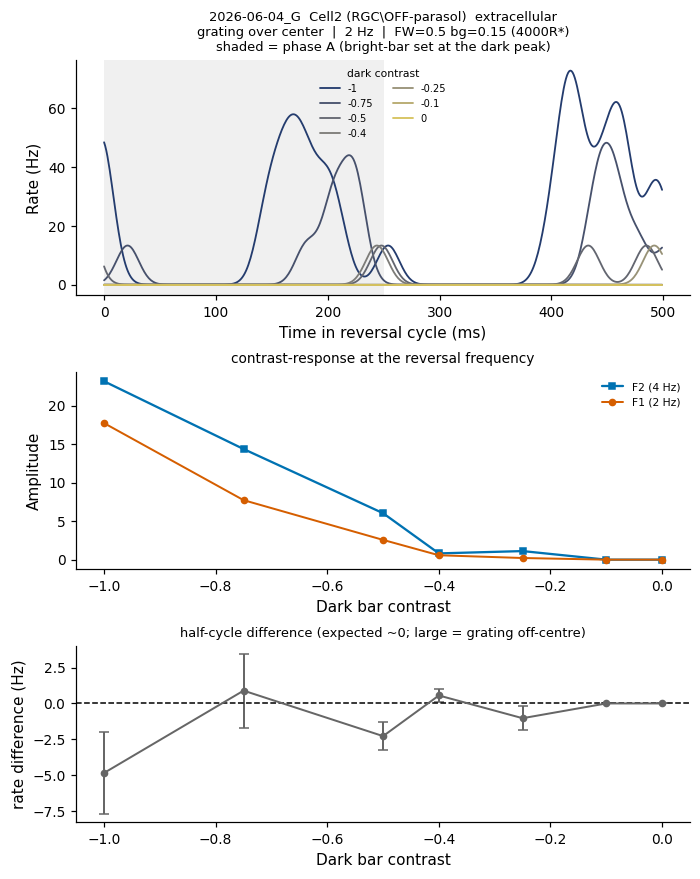

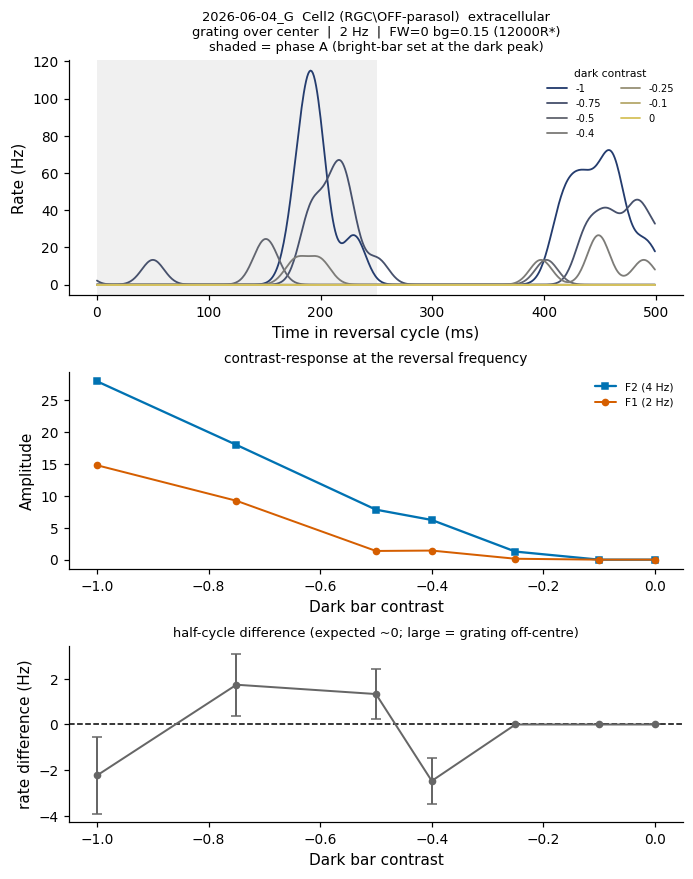

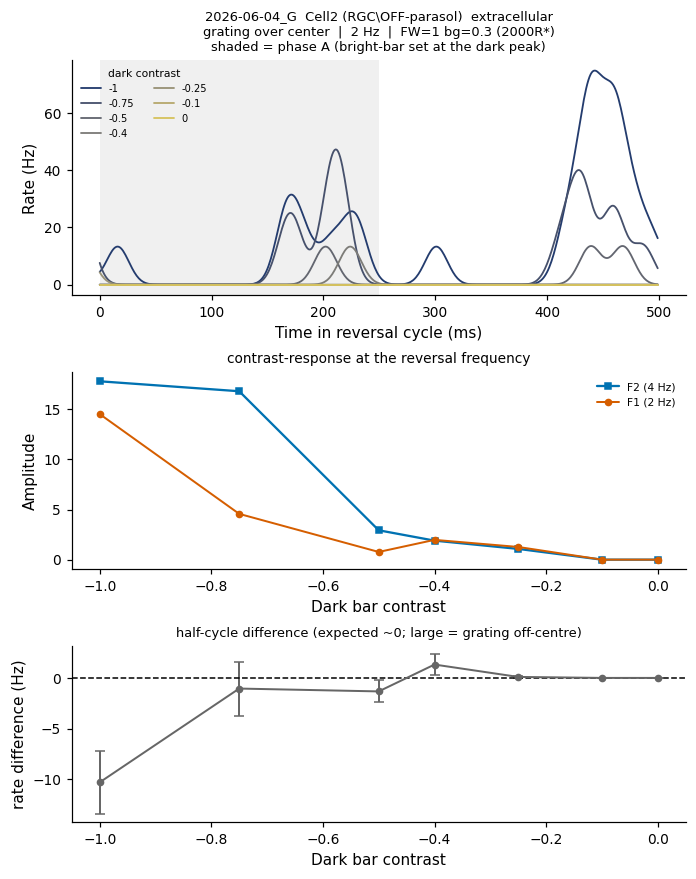

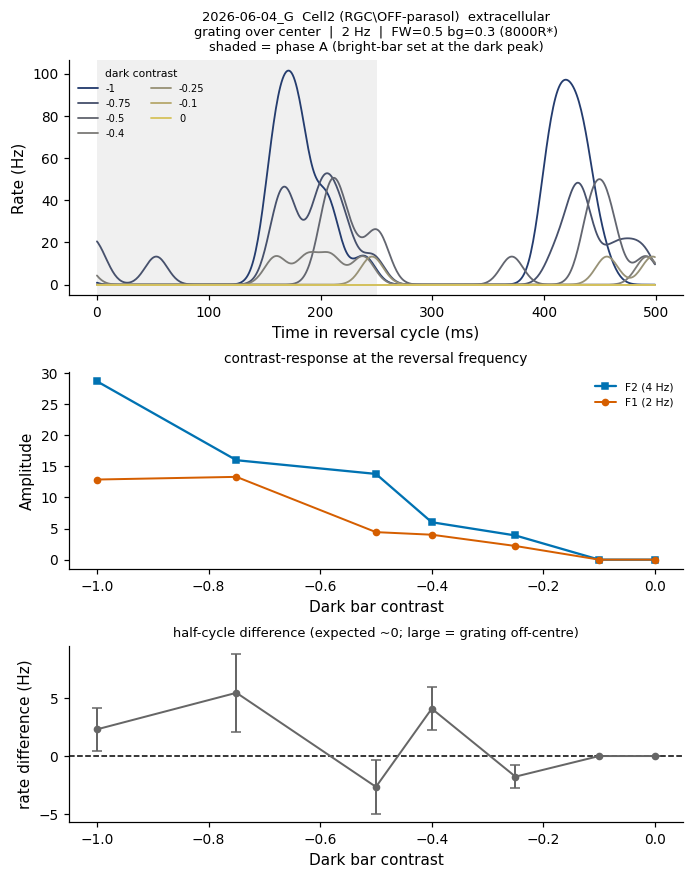

In [14]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-06-04_G/Cell2'

cell_records = crg.inspect_cell(CELL, canonical)